# **Diplomatura en Ciencia de Datos, Aprendizaje Automático y sus Aplicaciones**
*Edición 2023*

----

## **Introducción al Aprendizaje Automático**
## **Laboratorio 1: Regresión en California**

**GRUPO 11**
- Mendoza, Ruben Alfredo
- Risso, Sofia Agostina

En este laboratorio deben hacer experimentos de regresión con el conjunto de datos "California Housing dataset".

Estudiarán el dataset, harán visualizaciones y seleccionarán atributos relevantes a mano.

Luego, entrenarán y evaluarán diferentes tipos de regresiones, buscando las configuraciones que mejores resultados den.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.metrics as metrics

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import Ridge

## Carga del Conjunto de Datos

Cargamos el conjunto de datos y vemos su contenido.

In [2]:
X_california, y_california = fetch_california_housing(return_X_y=True, as_frame=True)
california = fetch_california_housing()

In [3]:
california.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'feature_names', 'DESCR'])

In [4]:
print(california['DESCR'])  # descripción del dataset
#california['feature_names'] # nombres de los atributos para cada columna de 'data'
#california['data']           # matriz con los datos de entrada (atributos)
#print(california['target']) # vector de valores a predecir

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

    :Number of Instances: 20640

    :Number of Attributes: 8 numeric, predictive attributes and the target

    :Attribute Information:
        - MedInc        median income in block group
        - HouseAge      median house age in block group
        - AveRooms      average number of rooms per household
        - AveBedrms     average number of bedrooms per household
        - Population    block group population
        - AveOccup      average number of household members
        - Latitude      block group latitude
        - Longitude     block group longitude

    :Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived

Traducción

La variable objetivo es el valor medio de la vivienda para los distritos de California, expresado en cientos de miles de dólares ($100,000).

Este conjunto de datos se deriva del censo de EE. UU. de 1990, utilizando una fila por grupo de bloques censales. Un grupo de bloques es la unidad geográfica más pequeña para la cual la Oficina del Censo de EE. UU. publica datos de muestra (un grupo de bloques generalmente tiene una población de 600 a 3,000 personas).

Un hogar es un grupo de personas que residen en una vivienda. Dado que el número promedio de habitaciones y dormitorios en este conjunto de datos se proporciona por hogar, estas columnas pueden tomar valores sorprendentemente altos para grupos de bloques con pocos hogares y muchas viviendas vacías, tales como resorts vacacionales.

In [5]:
california['data'].shape, california['target'].shape

((20640, 8), (20640,))

In [6]:
df = X_california.copy()
df['target'] = y_california
df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


En este conjunto de datos, se tienen 3 categorías de datos:

1) Información sobre la __demografía__ de los distritos:

    * *Population*: población del grupo de bloques
    * *AveOccup*: número medio de miembros del hogar
    
2) Información general sobre las __viviendas__ de los distritos:

    * *MedInc*: mediana de la renta del grupo de bloques
    * *AveRooms*: media de habitaciones por hogar
    * *AveBedrms*: media de dormitorios por hogar
    * *HouseAge*: mediana de la edad de la vivienda en el grupo de bloques
    

3) Información sobre la __ubicación__ de los distritos:

    * *Latitude*: latitud del grupo de bloques
    * *Longitude*: longitud del grupo de bloques


Dado que estas estadísticas se presentan a nivel de distrito, corresponden a promedios o medianas.

In [7]:
df = df.rename(columns={'MedInc': 'Ing_Med',
                        'HouseAge': 'House_Antiq',
                        'AveRooms': 'N_rooms',
                        'AveBedrms': 'N_bedr',
                        'Population': 'Distr_popul',
                        'AveOccup': 'House_Occup'})

In [8]:
df.describe()

,Ing_Med,House_Antiq,N_rooms,N_bedr,Distr_popul,House_Occup,Latitude,Longitude,target
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


A continuación se visualiza la distribución de estas características representando sus histogramas. Cabe aclarar que dichos gráficos fueron realizados luego de haber eliminado outliers, cuya decisión se tomó al observar datos anormales, como por ejemplo, bloques censales cuyas viviendas contaban con aproximadamente 135 habitaciones o alrededor de 35 dormitorios.

In [9]:
def plot_distribution(dataframe, column_name):

    column_data = dataframe[column_name]

    plt.figure(figsize=(12, 6))
    plt.hist(column_data, bins='auto', alpha=0.7, rwidth=0.85)
    plt.grid(axis='y', alpha=0.75)
    plt.xlabel(column_name)
    plt.ylabel('Frecuencia')
    plt.title('Distribución de {}'.format(column_name))

    # Calcular promedio, mediana y cuantiles
    mean_value = np.mean(column_data)
    median_value = np.median(column_data)
    quantiles = np.percentile(column_data, [25, 75])  # Cuantiles de 25% y 75%

    # Calcular rango conservado sin outliers según los criterios
    std_threshold = 3 * np.std(column_data)
    iqr_threshold = 1.5 * (quantiles[1] - quantiles[0])
    range_without_outliers_std = [mean_value - std_threshold, mean_value + std_threshold]
    range_without_outliers_iqr = [quantiles[0] - iqr_threshold, quantiles[1] + iqr_threshold]

    # Agregar líneas verticales para el promedio, mediana, cuantiles y rangos sin outliers
    plt.axvline(mean_value, color='r', linestyle='--', linewidth=2, label='Promedio')
    plt.axvline(median_value, color='g', linestyle='--', linewidth=2, label='Mediana')
    #plt.axvline(quantiles[0], color='b', linestyle='--', linewidth=2, label='Cuantil 25%')
    #plt.axvline(quantiles[1], color='b', linestyle='--', linewidth=2, label='Cuantil 75%')
    plt.axvline(range_without_outliers_std[0], color='m', linestyle='--', linewidth=2,
                label='Rango sin outliers (3 desviaciones estándar)')
    plt.axvline(range_without_outliers_std[1], color='m', linestyle='--', linewidth=2)
    plt.axvline(range_without_outliers_iqr[0], color='c', linestyle='--', linewidth=2,
                label='Rango sin outliers (distancia intercuartílica ampliada)')
    plt.axvline(range_without_outliers_iqr[1], color='c', linestyle='--', linewidth=2)

    plt.legend()
    plt.show()


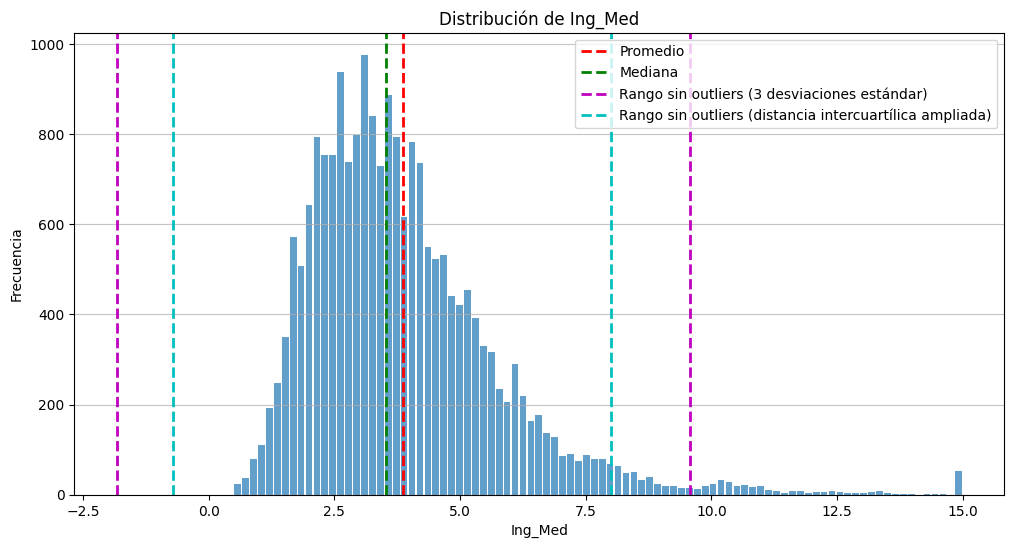

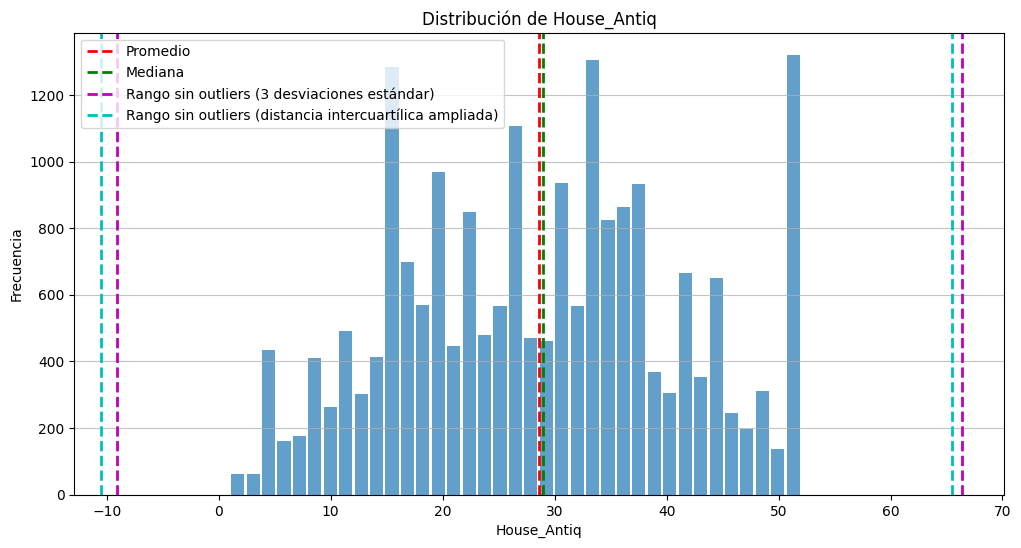

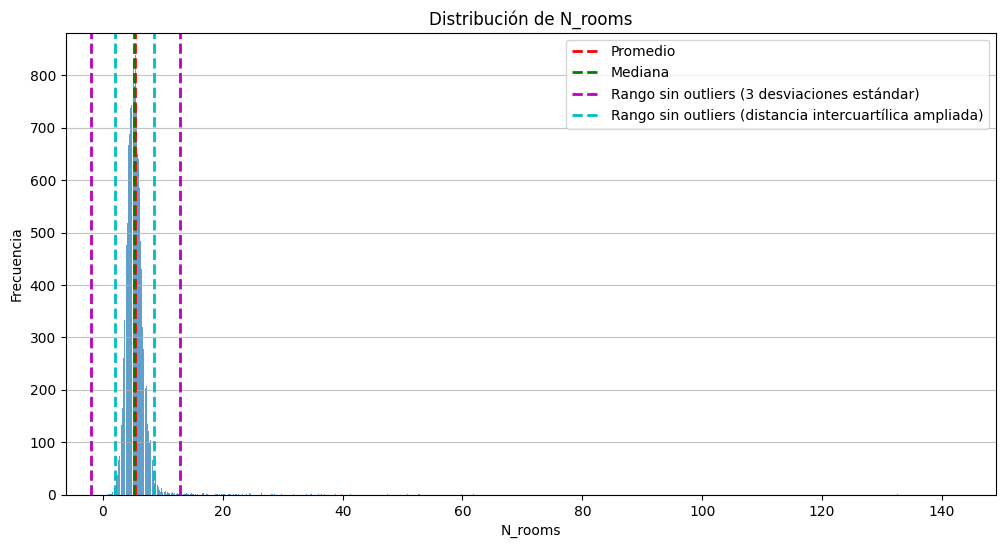

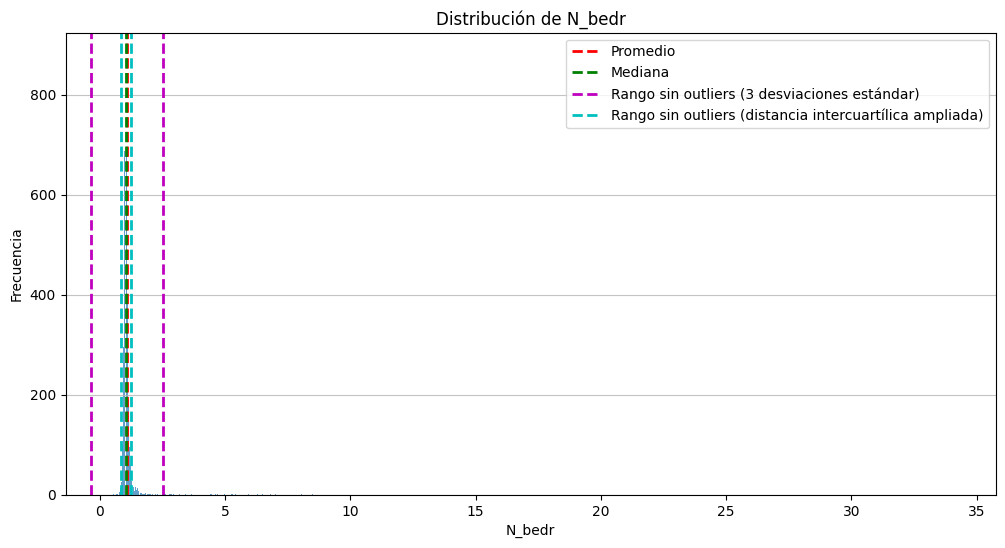

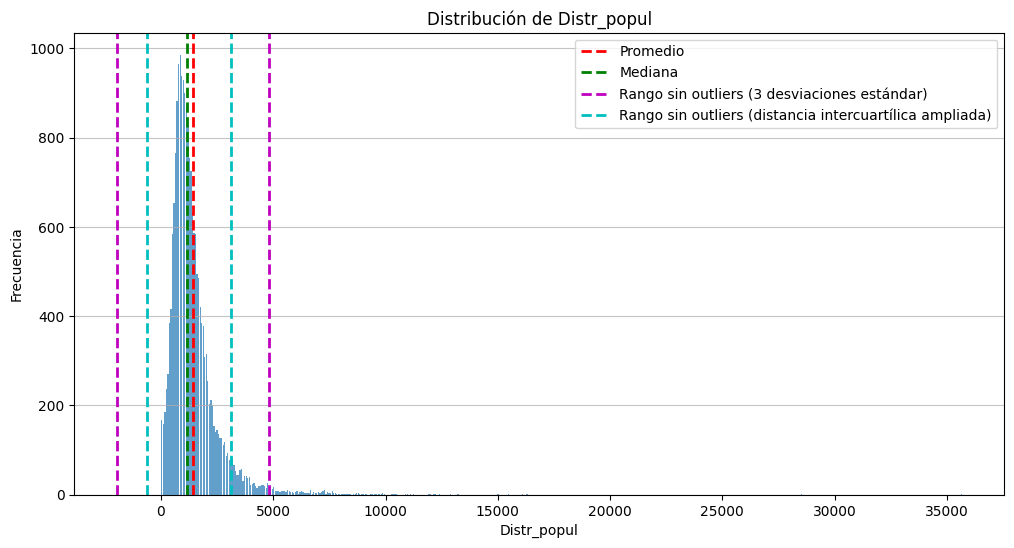

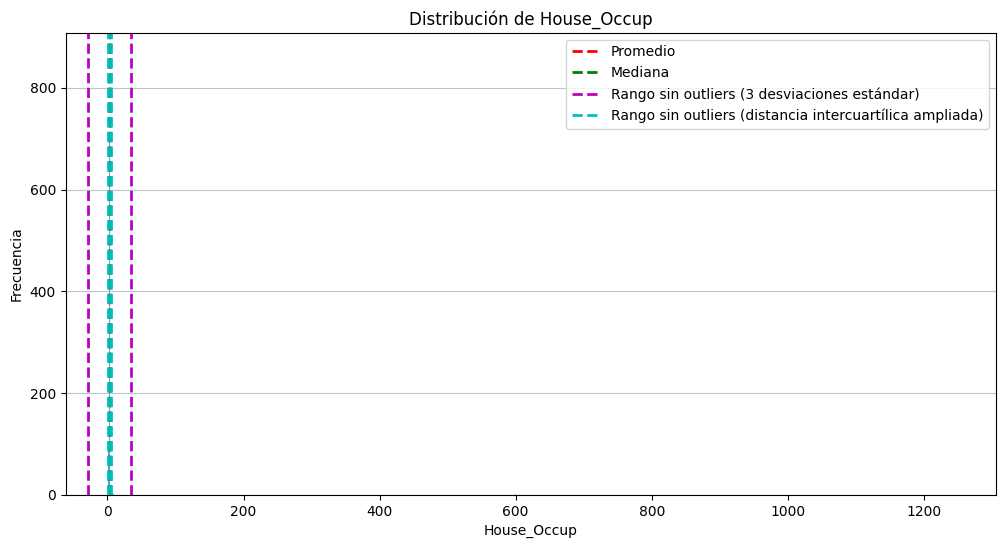

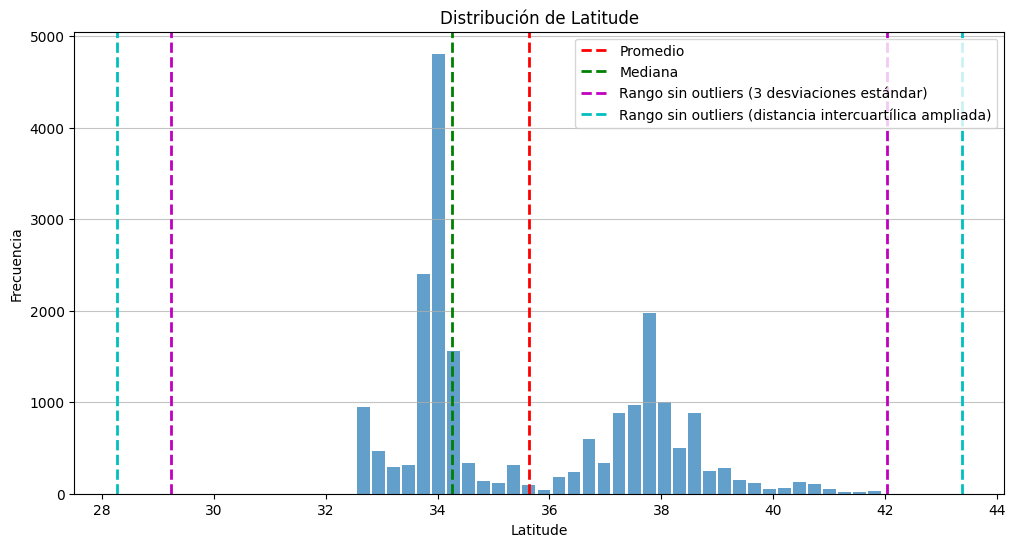

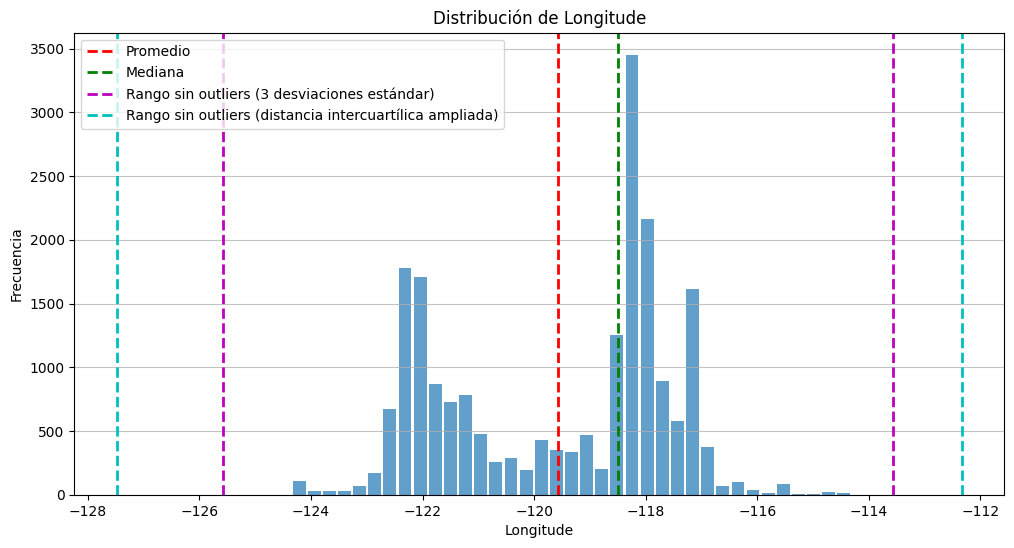

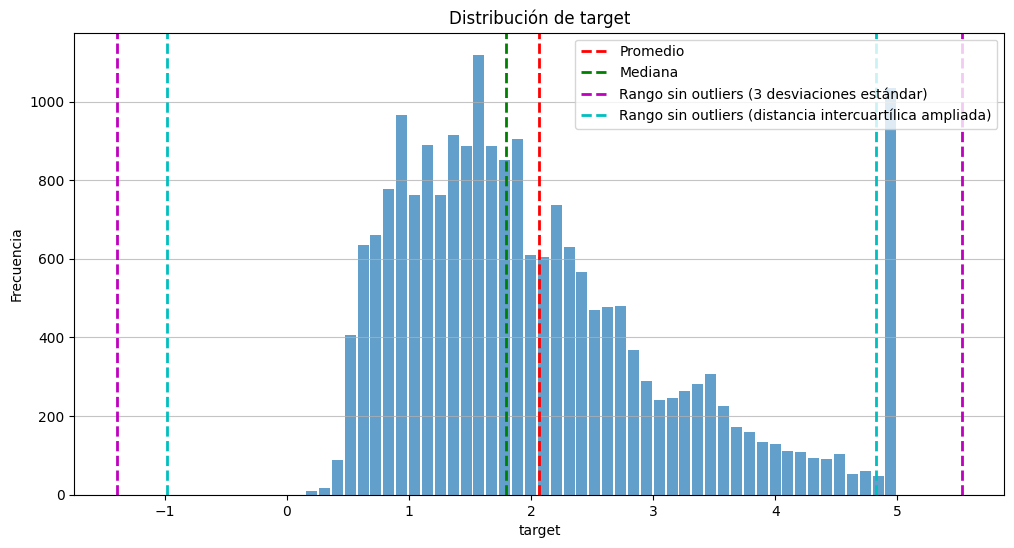

In [10]:
for name in df.columns:
    plot_distribution(df,name)

Para la eliminación de outliers se compararon dos métodos (distancia intercuartilica y tres desviaciones estandar) para analizar cuál de los dos eliminaba la menor cantidad de datos (filas).

In [11]:
def remove_outliers_quantiles(df):

    # Calcula los cuantiles del 25 y 75
    q25 = df.quantile(0.25)
    q75 = df.quantile(0.75)

    # Calcula el rango intercuartílico (IQR)
    iqr = q75 - q25

    # Define los límites inferior y superior
    lower_bound = q25 - 1.5 * iqr
    upper_bound = q75 + 1.5 * iqr

    # Filtra los outliers por columna
    mask = df.apply(lambda col: (col >= lower_bound[col.name]) & (col <= upper_bound[col.name]))
    filtered_df = df[mask.all(axis=1)]

    return filtered_df

In [12]:

    best_r2 = None  # Variable para almacenar el mejor coeficiente de determinacióndef remove_outliers_std(df, threshold=3):

    # Calcula la media y la desviación estándar para cada columna
    mean = df.mean()
    std = df.std()

    # Filtra los outliers por columna
    mask = df.apply(lambda col: (col >= mean[col.name] - threshold * std[col.name]) & (col <= mean[col.name] + threshold * std[col.name]))
    filtered_df = df[mask.all(axis=1)]

    return filtered_df

Luego se visualizó cómo quedaron los dataset limpios en ambos casos.

In [13]:
df_qua_clean = remove_outliers_quantiles(df)
df_std_clean = remove_outliers_std(df)

In [14]:
len(df_qua_clean), len(df_std_clean)

(16312, 19794)

Con cada criterio de eliminación de outliers se eliminan cantidades diferentes de datos. El criterio que usa la distancia intercuartilica elimina más datos que el criterio que usa la desviacion estandar.

In [15]:
def plot_distribution_comparation(dataframe1, dataframe2, column_name):
    column_data1 = dataframe1[column_name]
    column_data2 = dataframe2[column_name]

    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    # Gráfica para el dataframe 1
    axes[0].hist(column_data1, bins='auto', alpha=0.7, rwidth=0.85)
    axes[0].grid(axis='y', alpha=0.75)
    axes[0].set_xlabel(column_name)
    axes[0].set_ylabel('Frecuencia')
    axes[0].set_title('Criterio de Cuantiles')

    # Gráfica para el dataframe 2
    axes[1].hist(column_data2, bins='auto', alpha=0.7, rwidth=0.85)
    axes[1].grid(axis='y', alpha=0.75)
    axes[1].set_xlabel(column_name)
    axes[1].set_ylabel('Frecuencia')
    axes[1].set_title('Criterio de Desviacion Estandar')

    plt.tight_layout()
    plt.show()

Se visualizaron ambos criterios para ver sus diferencias.

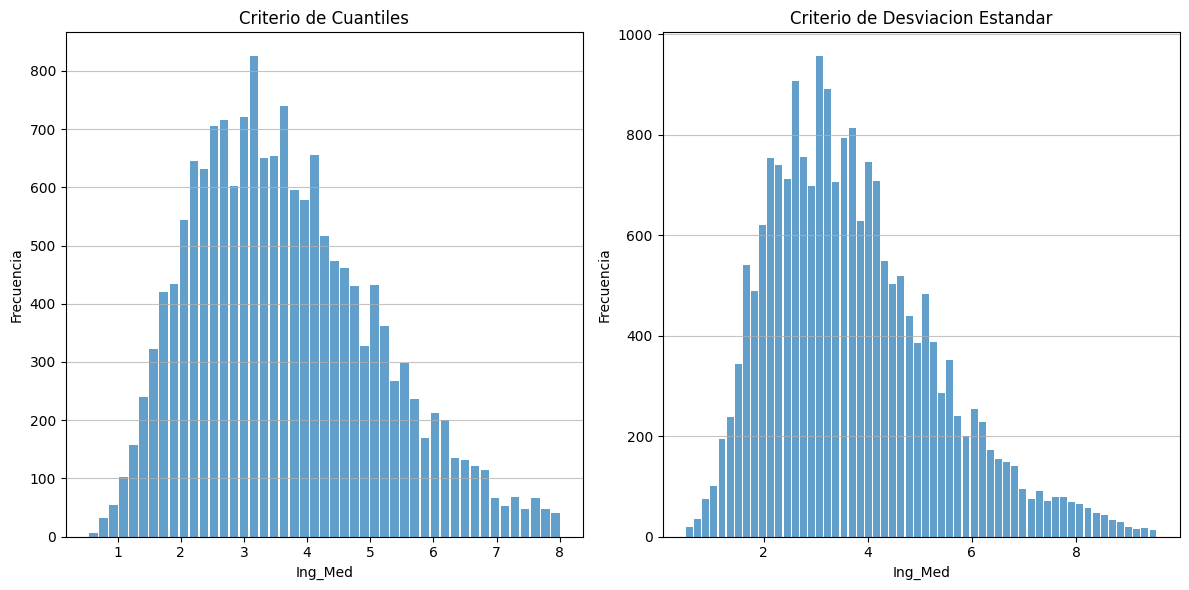

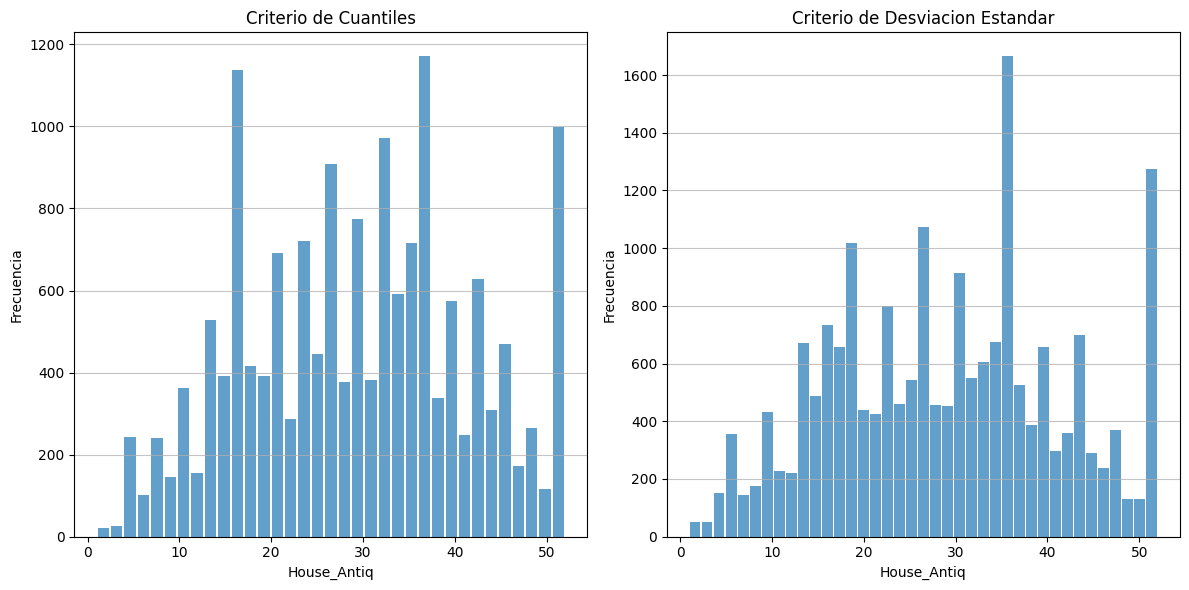

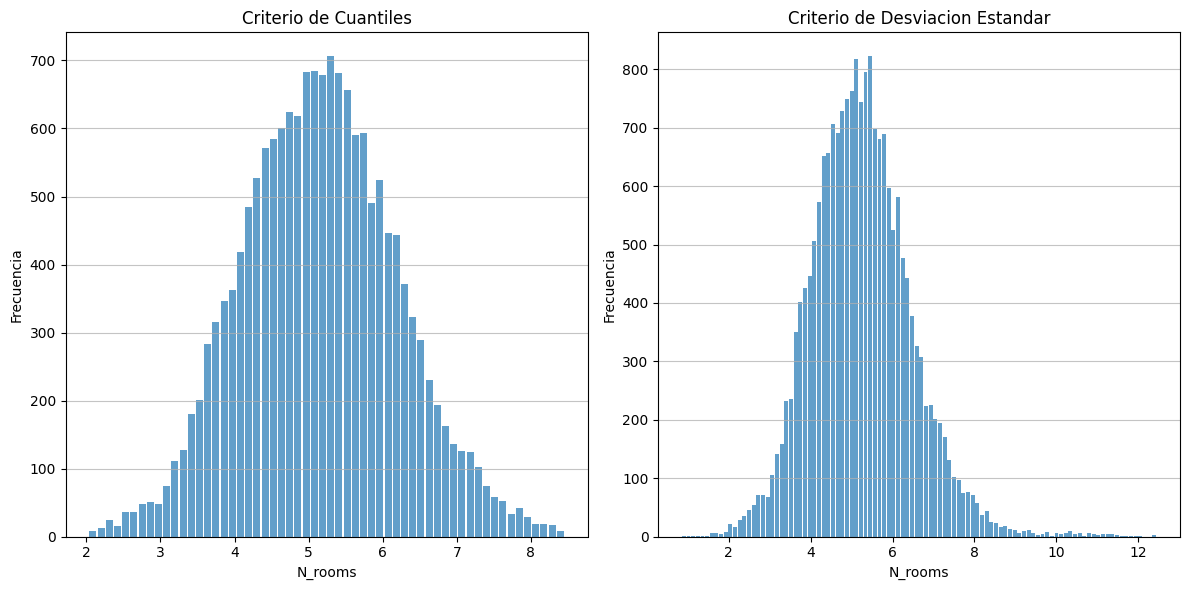

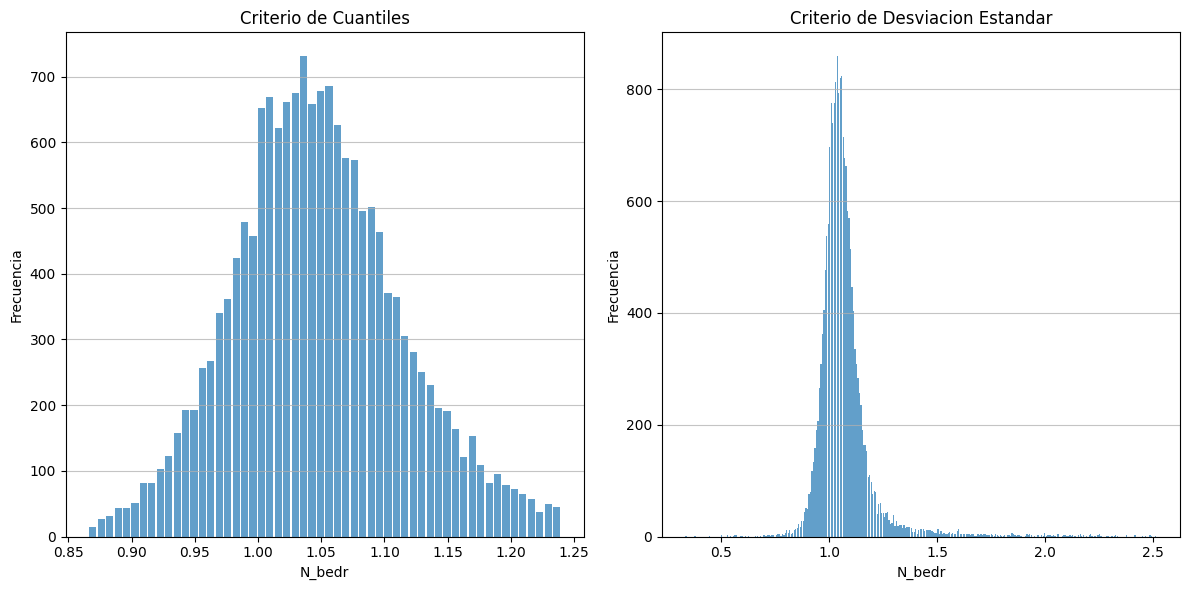

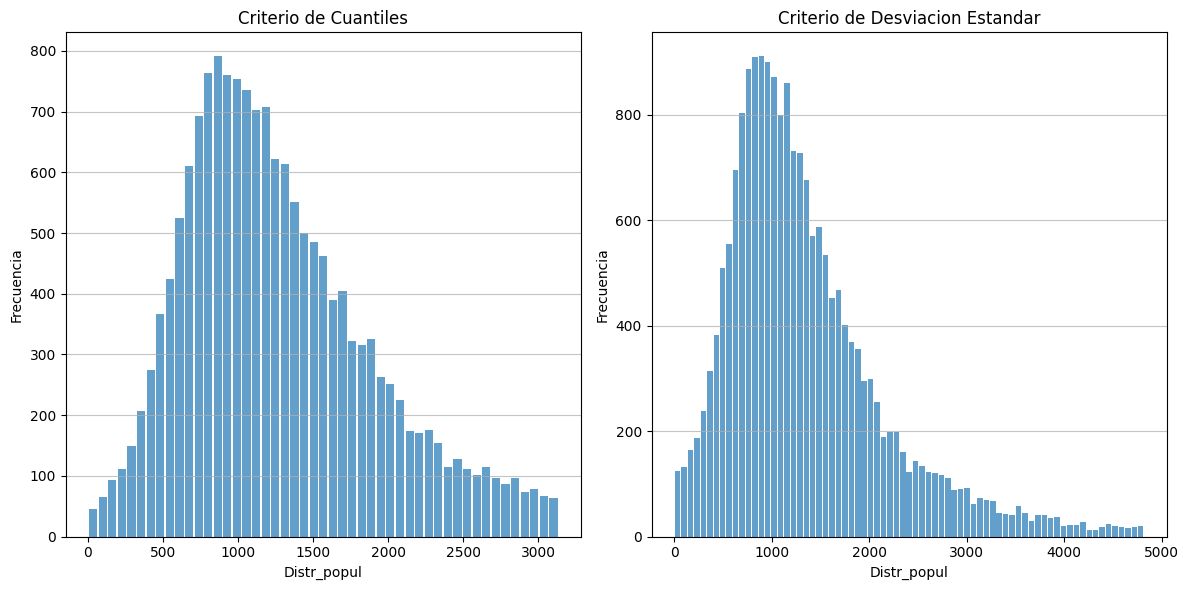

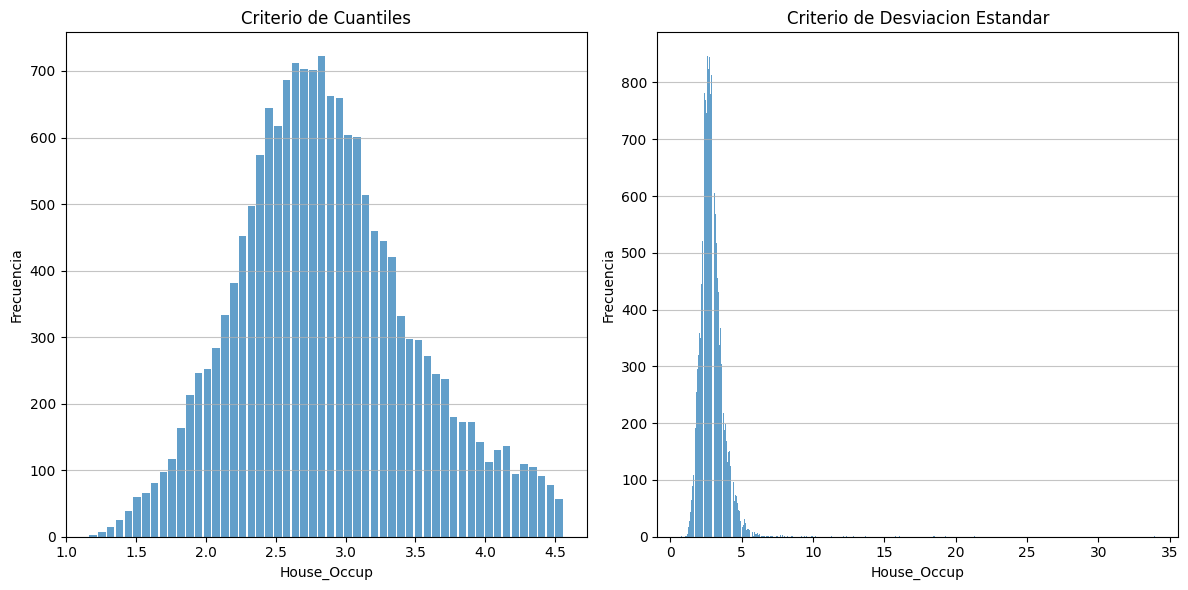

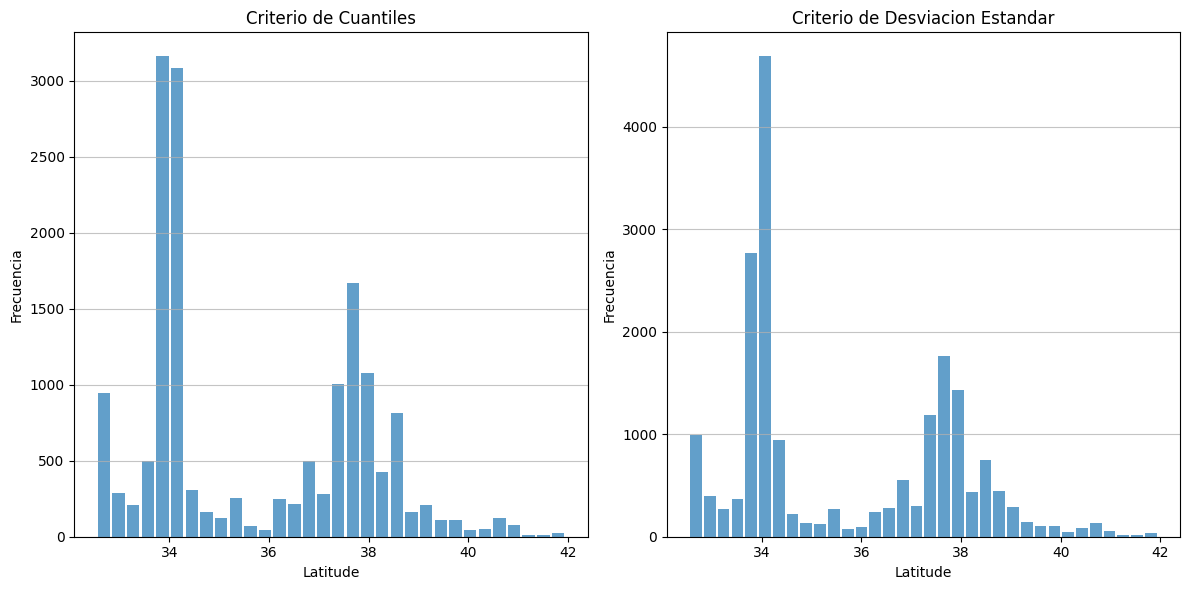

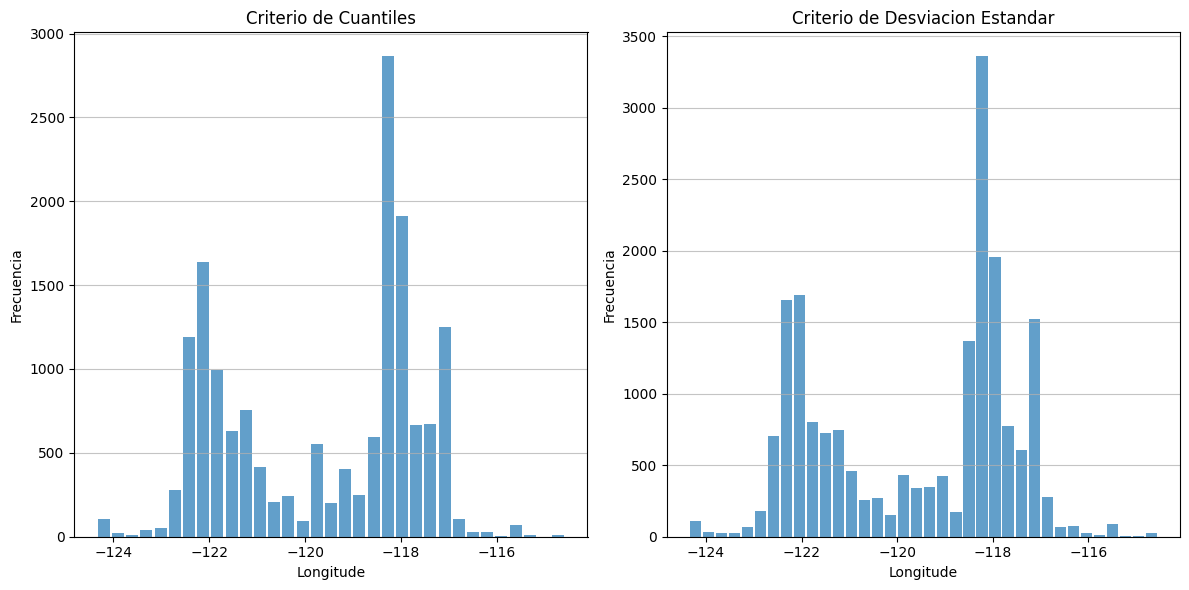

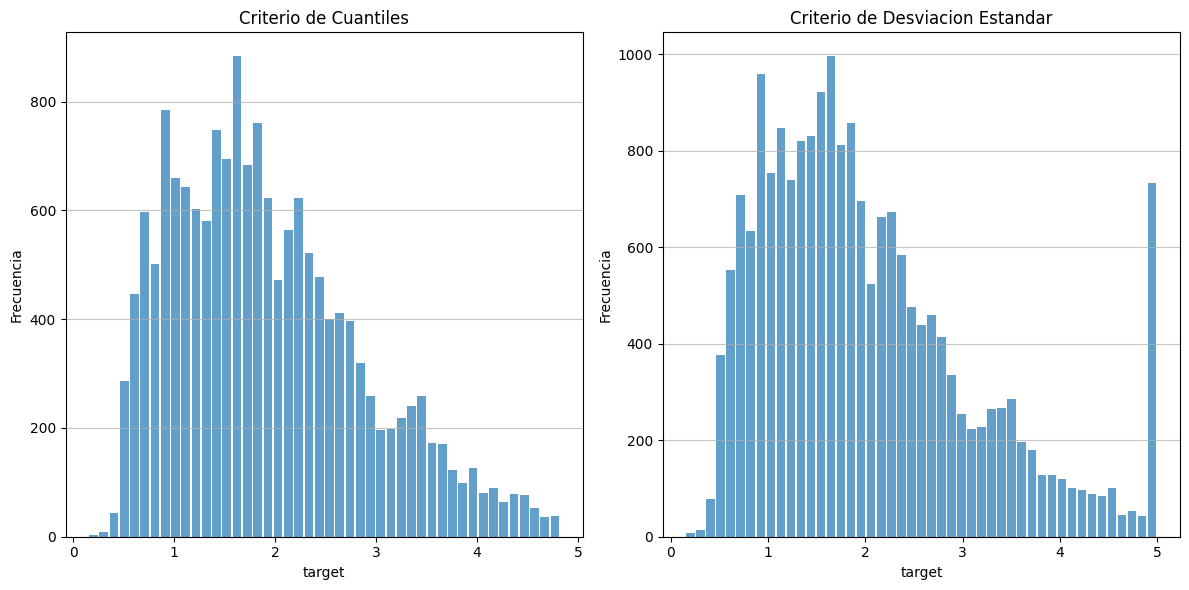

In [16]:
for name in df.columns:
    plot_distribution_comparation(df_qua_clean, df_std_clean, name)

Es importante recordar que debido al gran sesgo que hay en los datos, la **media** no es una medida representativa de los mismos por estar muy influenciada por valores extremos. Por lo tanto, optar por el uso del criterio de las 3 desviaciones estandar no es una buena decisión.

In [17]:
X_california, y_california = df_qua_clean.drop(['target'], axis = 1), df_qua_clean['target']

In [18]:
X_california.shape, y_california.shape

((16312, 8), (16312,))

## División en Entrenamiento y Evaluación

Dividimos aleatoriamente los datos en 80% para entrenamiento y 20% para evaluación:

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X_california, y_california, train_size=0.8, random_state=0)

In [20]:
print("Forma de X_train:", X_train.shape)
print("Forma de X_test:", X_test.shape)
print("Forma de y_train:", y_train.shape)
print("Forma de y_test:", y_test.shape)

Forma de X_train: (13049, 8)
Forma de X_test: (3263, 8)
Forma de y_train: (13049,)
Forma de y_test: (3263,)


## Ejercicio 1: Descripción de los Datos y la Tarea

Responda las siguientes preguntas:

1. **¿De qué se trata el conjunto de datos?**
    
  El presente conjunto de datos proviene de un censo realizado en 1990 en EE. UU., más precisamente, en el estado de California.


2. **¿Cuál es la variable objetivo que hay que predecir? ¿Qué significado tiene?**

     La variable objetivo que se debe predecir es la mediana del valor de las viviendas (expresado en cientos de miles de dólares) para un bloque censal de un determinado distrito del Estado de California. En otras palabras, el valor de una vivienda de un bloque censal determinado es la mediana de los valores de las viviendas del bloque censal en el que se encuentra.


3. **¿Qué información (atributos) hay disponibles para hacer la predicción?**

 Existen 8 atributos disponibles que posibilitan realizar la predicción:
   - *MedInc*: mediana de la renta del grupo de bloques
   - *HouseAge*: mediana de la edad de la vivienda en el grupo de bloques
   - *AveRooms*: media de habitaciones por hogar
   - *AveBedrms*: media de dormitorios por hogar
   - *Population*: población del grupo de bloques
   - *AveOccup*: número medio de miembros del hogar
   - *Latitude*: latitud del grupo de bloques
   - *Longitude*: longitud del grupo de bloques
   
   
4. **¿Qué atributos imagina ud. que serán los más determinantes para la predicción?** VER CUALES DEJAMOS DE ESTAS
        
 Se considera que los atributos más determinantes para realizar la predicción son:

  - *MedInc*: asumiendo que este atributo está asociado con la geolocalización de las viviendas, se puede pensar que los grupos de bloques censales más cercanos a lugares de interés públicos (por ejemplo: zona céntrica, casa de gobierno, etc.) tendrán un valor medio mayor comparado con viviendas ubicadas en la periferia.

  - *HouseAge*: este atributo puede ser tomado desde dos puntos de vista diferentes: por un lado, las viviendas más antiguas podrían ser las más costosas ya que forman parte del patrimonio cultural de la zona en la que se encuentran emplazadas; por otro, las más costosas podrían ser las más modernas como consecuencia de sus costos de construcción y bajo mantenimiento.

  - *AveRooms* y *AveBedrms*: mientras mayor número de habitaciones o dormitorios presenta una vivienda, será más grande, por ende será más costosa.


5. **¿Qué problemas observa a priori en el conjunto de datos? ¿Observa posibles sesgos, riesgos, dilemas éticos, etc? Piense que los datos pueden ser utilizados para hacer predicciones futuras**.

 En función a los gráficos de previsualización realizados anteriormente, una de las observaciones que llaman más la atención es que de la totalidad de viviendas existentes en cada grupo censal, muy pocas se hallan ocupadas. Además, a juzgar por  la frecuencia en el número de habitaciones, se trataría de viviendas de gran tamaño constituidas por numerosas habitaciones (incluídos los dormitorios).
 Por otra parte, ciertos gráficos de previsualización como la distribución de frecuencias para el número de habitaciones y dormitorios, exhiben valores en su eje X un tanto anormales (considerando que las dimensiones del código utilizado para realizar estos gráficos se ajusta de manera automática). Por ejemplo, según estos gráficos, existen bloques censales cuyas viviendas cuentan con aproximadamente 145 habitaciones o alrededor de 35 dormitorios, respectivamente. Sin embargo, esto podría deberse a que el cálculo de  fue realizado considerando todas las habitaciones y dormitorios en total de cada grupo censal y no por vivienda particular.



## Ejercicio 2: Visualización de los Datos

1. Para cada atributo de entrada, haga una gráfica que muestre su relación con la variable objetivo.
2. Estudie las gráficas, identificando a ojo los atributos que a su criterio sean los más informativos para la predicción.
3. Para ud., ¿cuáles son esos atributos? Lístelos en orden de importancia.


Para cada atributo de entrada se realizó una gráfica para demostrar su relación con la variable objetivo.

In [22]:
def scatterplot(df_x,col_name, df_y):
    # Crear la figura y los ejes
    fig, ax = plt.subplots(figsize=(12, 8))  # Ajusta el tamaño de la figura según tus necesidades

    # Crear el scatter plot
    ax.scatter(df_x[col_name], df_y, facecolor="dodgerblue", edgecolor="k")  # 'target' es la columna objetivo (y) en el dataframe

    # Configurar el título y las etiquetas de los ejes
    ax.set_title(col_name)
    ax.set_xlabel(col_name)
    ax.set_ylabel('Target')

    # Añadir leyenda
    ax.legend()

    # Ajustar los límites de los ejes
    ax.set_xlim(df_x[col_name].min() - df_x[col_name].std(), df_x[col_name].max() + df_x[col_name].std())
    ax.set_ylim(df_y.min()-1, df_y.max()+1)

    # Mostrar el plot
    plt.show()

In [23]:
for name in X_california.columns:
    scatterplot(X_california,name,y_california)
    plt.show()

Output hidden; open in https://colab.research.google.com to view.

En base a las gráficas presentadas anteriormente, y realizando un análisis superficial (a "ojo"), los atributos más informativos para la predicción fueron `Ing_Med` y `N_rooms` debido a que las mismas exhiben claramente una pendiente. Para corroborar lo mencionado, se realizó, además, el cálculo de correlación entre la variable objetivo y los diferentes atributos.

In [24]:
def calculate_correlation(data, serie):
    # Calcular la correlación entre el dataframe y la serie
    correlation = data.corrwith(serie)

    # Crear un nuevo dataframe con los resultados de correlación
    corr_df = pd.DataFrame(correlation, columns=['Correlation'])

    # Ordenar los resultados de correlación en orden descendente por valor absoluto
    corr_df['Absolute Correlation'] = corr_df['Correlation'].abs()
    corr_df = corr_df.sort_values(by='Absolute Correlation', ascending=False)

    # Eliminar la columna de valor absoluto de correlación
    corr_df = corr_df.drop(columns=['Absolute Correlation'])

    return corr_df


In [25]:
calculate_correlation(X_california, y_california)

,Correlation
Ing_Med,0.632971
House_Occup,-0.275504
N_rooms,0.260237
Latitude,-0.150479
N_bedr,-0.099079
House_Antiq,0.087911
Longitude,-0.043103
Distr_popul,-0.005995


A partir de dicha tabla fue posible corroborar lo mencionado anteriormente y determinar el orden de importancia que tiene cada atributo para realizar la predicción como se muestra a continuación:
 - Ing_Med
 - House_Occup
 - N_rooms

 `Ing_Med` y `N_rooms` se correlacionan positivamente con la variable objetivo. Esto significa que, a medida que aumenten los valores de estos atributos, también lo hará la variable objetivo. En otras palabras, a medida que la mediana de la renta de las viviendas de un determinado bloque censal sea mayor o que la vivienda cuente con una mayor cantidad de habitaciones, su costo será mayor.

 Al contrario, `House_Occup` se correlaciona negativamente con la variable objetivo, es decir que, a medida que los valores de este atributo se incrementan, los valores de la variable objetivo disminuyen. En otras palabras, a medida que se incrementa el número medio de miembros del hogar, el costo de una vivienda disminuye.

## Ejercicio 3: Regresión Lineal

1. Seleccione **un solo atributo** que considere puede ser el más apropiado.
2. Instancie una regresión lineal de **scikit-learn**, y entrénela usando sólo el atributo seleccionado.
3. Evalúe, calculando error cuadrático medio para los conjuntos de entrenamiento y evaluación.
4. Grafique el modelo resultante, junto con los puntos de entrenamiento y evaluación.
5. Interprete el resultado, haciendo algún comentario sobre las cualidades del modelo obtenido.

**Observación:** Con algunos atributos se puede obtener un error en test menor a 50.

Se seleccionó el atributo `Ing_Med` como el más apropiado para entrenar el modelo de Regresión Lineal, ya que fue el que mayor correlación tuvo con la variable objetivo de todos los atributos.

Una vez definidos los datos, se estandarizaron para poder entrenar el modelo. Para esto se crearon dos instancias de la clase `StandardScaler()` donde la primera escaló los datos de "X" mientras que la segunda escaló los datos de "y". Además, se aplicó la funcion `.fit()`, la cual calculó los parámetros necesarios (como la media y la desviación estandar) para realizar la transformación.

A su vez, es importante resaltar que el `.fit()` se realizó con los datos de entrenamiento (X_train) y no con los datos completos (X_train + X_test). La razón de dicho procedimiento fue para que el método escalador se "entrenara" únicamente con los datos de entrenamiento y los datos de prueba se mantuvieran ocultos. Sin embargo, al aplicar el método escalador para transformar los datos, se tuvieron en cuenta ambos dataset.

In [26]:
x_Ing_Med_train = X_train.Ing_Med.values.reshape(-1,1)
x_Ing_Med_test = X_test.Ing_Med.values.reshape(-1,1)

y_train = y_train.values.reshape(-1,1)
y_test = y_test.values.reshape(-1,1)

In [27]:
sc_x = StandardScaler().fit(x_Ing_Med_train)
sc_y = StandardScaler().fit(y_train)

Notar que aqui la funcion `.values` tomó todos los valores de la columna y los colocó en un arreglo, es decir, se pasó de tener números en una estructura de DataFrame a tenerlos en una estructura de arreglo, más específicamente, en un vector fila. Por su parte, la función `.reshape(-1,1)` transformó los datos que se encontraban en un vector fila en datos ordenados en un vector columna.

In [28]:
x_Ing_Med_train = sc_x.transform(x_Ing_Med_train)
x_Ing_Med_test = sc_x.transform(x_Ing_Med_test)

y_train = sc_y.transform(y_train)
y_test = sc_y.transform(y_test)

Una forma alternativa de realizar los pasos anteriores y arribar al mismo resultado es de la siguiente manera:

```python
sc_x = StandardScaler()
sc_y = StandardScaler()

X_Ing_Med_train = sc_x.fit_transform(X_Ing_Med_train)
y_train = sc_y.fit_transform(y_train)

X_Ing_Med_test = sc_x.transform(X_Ing_Med_test)
y_test = sc_y.transform(y_test)
```

La diferencia es que aquí, habríamos entrenado el escalador y luego transformado los datos en un solo método con `fit_transform()`. Luego, se habría podido escalar cualquier otro dataset con el escalador ya entrenado, estando "limpio" de informacion del dataset de prueba.

Luego del procedimiento anterior, se inició una instancia de `LinealRegression()` para crear el modelo y luego entrenarlo.

In [29]:
lin_reg = LinearRegression()

Posteriormente, se creó la linea recta que mejor se ajustaba a los datos. Esto es, se entrenó el modelo.

In [30]:
lin_reg.fit(x_Ing_Med_train, y_train)

LinearRegression()

In [31]:
y_predict = lin_reg.predict(x_Ing_Med_test)

Seguidamente, se evaluó el modelo calculando el error cuadrático medio para los conjuntos de evaluación.

In [32]:
mse = metrics.mean_squared_error(y_test, y_predict)
r2 = metrics.r2_score(y_test, y_predict)

print(f"Error Cuadrático Medio (MSE): {mse:.4f}")
print(f"Coeficiente de Determinación (R^2): {r2:.4f}")

Error Cuadrático Medio (MSE): 0.5706
Coeficiente de Determinación (R^2): 0.4112


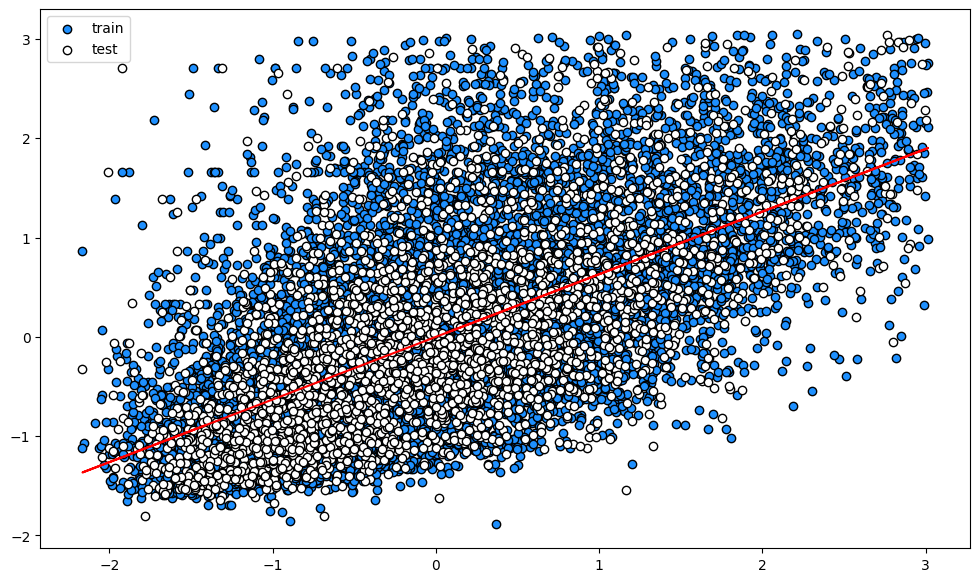

In [33]:
plt.figure(figsize=(12,7))
plt.scatter(x_Ing_Med_train, y_train, color = 'green', facecolor="dodgerblue", edgecolor="k", label="train")
plt.scatter(x_Ing_Med_test, y_test, facecolor="white", edgecolor="k", label="test")
plt.plot(x_Ing_Med_train, lin_reg.predict(x_Ing_Med_train), color = 'red')
plt.legend();

In [34]:
coefficients = lin_reg.coef_
coefficients

array([[0.63086349]])

## Ejercicio 4: Regresión Polinomial

En este ejercicio deben entrenar regresiones polinomiales de diferente complejidad, siempre usando **scikit-learn**.

Deben usar **el mismo atributo** seleccionado para el ejercicio anterior.

1. Para varios grados de polinomio, haga lo siguiente:
    1. Instancie y entrene una regresión polinomial.
    2. Prediga y calcule error en entrenamiento y evaluación. Imprima los valores.
    3. Guarde los errores en una lista.
2. Grafique las curvas de error en términos del grado del polinomio.
3. Interprete la curva, identificando el punto en que comienza a haber sobreajuste, si lo hay.
4. Seleccione el modelo que mejor funcione, y grafique el modelo conjuntamente con los puntos.
5. Interprete el resultado, haciendo algún comentario sobre las cualidades del modelo obtenido.

**Observación:** Con algunos atributos se pueden obtener errores en test menores a 40 e incluso a 35.

In [35]:
def polynomial_regression(X_train, X_test, y_train, y_test, degrees):
    train_errors = []  # Lista para almacenar los errores cuadráticos medios de entrenamiento
    val_errors = []  # Lista para almacenar los errores cuadráticos medios de validación

    best_model = None  # Variable para almacenar el mejor modelo
    best_val_err = float('inf')  # Variable para almacenar el menor error de validación encontrado
    best_r2 = None  # Variable para almacenar el mejor coeficiente de determinación

    # Iterar sobre los grados y ajustar las regresiones polinomiales
    for degree in degrees:
        model = make_pipeline(PolynomialFeatures(degree=degree), LinearRegression())  # Crear el pipeline para la regresión polinomial
        model.fit(X_train, y_train)  # Ajustar el modelo de regresión polinomial

        y_train_pred = model.predict(X_train)  # Realizar predicciones en los datos de entrenamiento
        y_val_pred = model.predict(X_test)  # Realizar predicciones en los datos de validación

        train_err = metrics.mean_squared_error(y_train, y_train_pred)  # Calcular el error cuadrático medio de entrenamiento
        val_err = metrics.mean_squared_error(y_test, y_val_pred)  # Calcular el error cuadrático medio de validación

        train_errors.append(train_err)  # Agregar el error de entrenamiento a la lista
        val_errors.append(val_err)  # Agregar el error de validación a la lista

        r2 = metrics.r2_score(y_test, y_val_pred)  # Calcular el coeficiente de determinación (R²)

        if val_err < best_val_err:  # Verificar si el error de validación actual es menor que el mejor error de validación encontrado hasta el momento
            best_val_err = val_err  # Actualizar el mejor error de validación
            best_model = model  # Actualizar el mejor modelo
            best_r2 = r2  # Actualizar el mejor coeficiente de determinación

    # Obtener el mejor modelo
    best_degree = degrees[val_errors.index(min(val_errors))]  # Obtener el grado correspondiente al menor error de validación
    print("Mejor grado del modelo:", best_degree)
    print("Coeficiente de determinación (R²):", best_r2)

    # Graficar el mejor modelo
    X_plot = np.linspace(min(X_train), max(X_train), 100).reshape(-1, 1)  # Generar puntos para graficar el modelo
    y_plot = best_model.predict(X_plot)  # Realizar predicciones en los puntos generados

    plt.figure(figsize=(12,6))
    plt.scatter(X_train, y_train, color = 'green', facecolor="dodgerblue", edgecolor="k", label="train")  # Graficar los puntos de entrenamiento
    plt.scatter(X_test, y_test, facecolor="white", edgecolor="k", label="test")  # Graficar los puntos de validación
    plt.plot(X_plot, y_plot, color='red', label='Best Model')  # Graficar el mejor modelo
    plt.xlabel('X')  # Etiqueta del eje x
    plt.ylabel('y')  # Etiqueta del eje y
    plt.title('Polynomial Regression')  # Título del gráfico
    plt.legend()  # Mostrar la leyenda
    plt.show()  # Mostrar el gráfico

    return train_errors, val_errors  # Devolver los errores cuadráticos medios de entrenamiento y validación


In [36]:
degrees = [i for i in range(1,40)]

Mejor grado del modelo: 6
Coeficiente de determinación (R²): 0.417361926581864


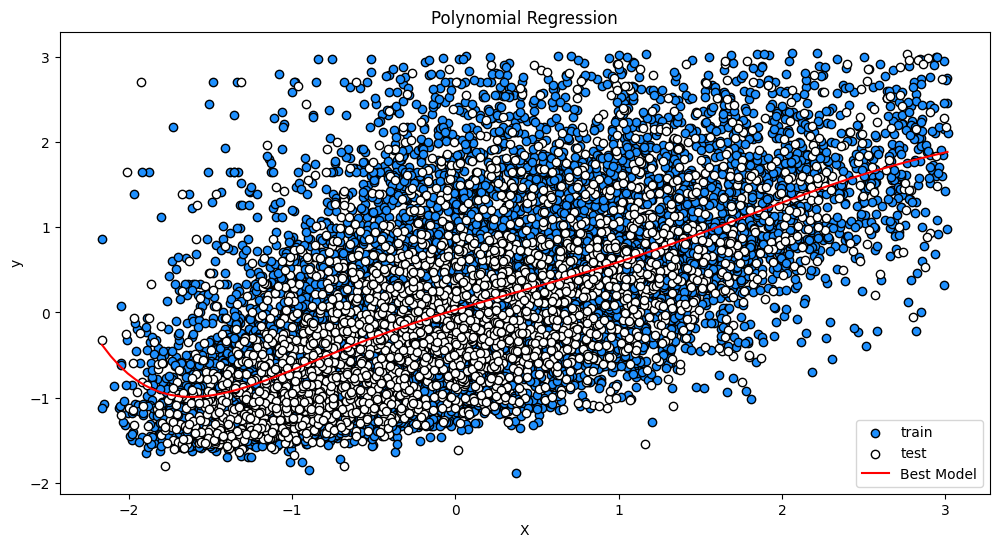

In [37]:
errors = polynomial_regression(x_Ing_Med_train, x_Ing_Med_test, y_train, y_test, degrees)

En función a lo obtenido, un polinomio de grado 6 sería el que mejor ajusta la dispersión de puntos. Sin embargo al ver e coeficiente de determinanción vemos que no ha mejorado casi el rendimiento del modelo.

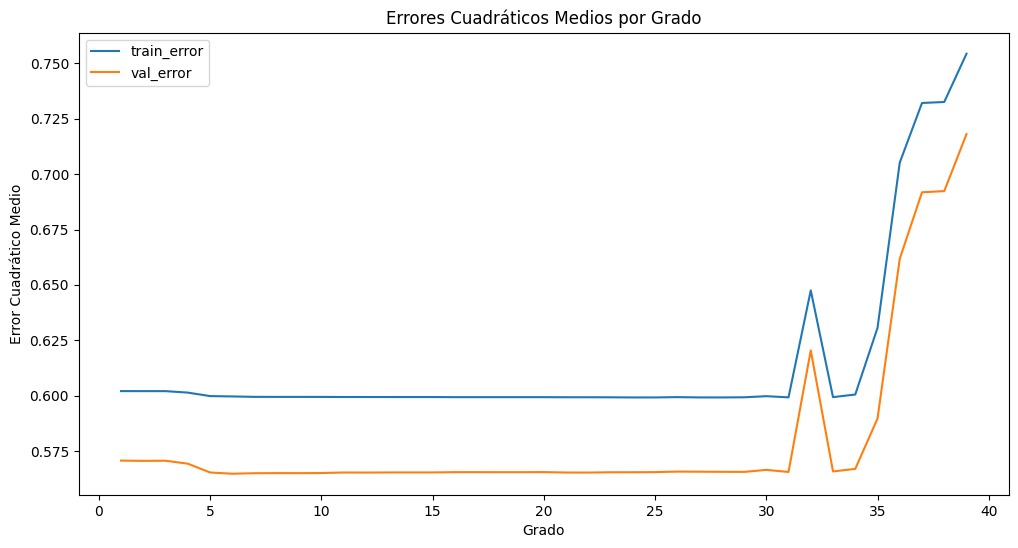

In [38]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(degrees, errors[0], label = 'train_error')
ax.plot(degrees, errors[1], label = 'val_error')
#ax.set_yscale('log')
#ax.set_xscale('log')
ax.set_xlabel('Grado')
ax.set_ylabel('Error Cuadrático Medio')
ax.set_title('Errores Cuadráticos Medios por Grado')
ax.legend()
plt.show();

**NOTA**: lo observado en el gráfico no es lo que se esperaría, es decir, el error de los valores de entrenamiento (`train_error`) no debería ser mayor al error de los datos de evaluación o prueba (`val_error`). Esto podría deberse a un sobreajuste u 'overfitting' del modelo.

Inicialmente, se observa cómo al aumenta el grado del polinomio, el Error Cuadrático Medio (MSE) disminuye, lo que indica que el modelo mejora su ajuste a los datos de entrenamiento. Sin embargo, al aumentar el grado del polinomio, se observa cómo el MSE comienza a aumentar nuevamente, lo que indica que el modelo se está sobreajustando y está perdiendo capacidad de generalización. Esto es posible verlo a partir del grado 30 aproximadamente, en donde se percibe un aumento considerable del MSE.

## Ejercicio 5: Regresión con más de un Atributo

En este ejercicio deben entrenar regresiones que toman más de un atributo de entrada.

1. Seleccione **dos o tres atributos** entre los más relevantes encontrados en el ejercicio 2.
2. Repita el ejercicio anterior, pero usando los atributos seleccionados. No hace falta graficar el modelo final.
3. Interprete el resultado y compare con los ejercicios anteriores. ¿Se obtuvieron mejores modelos? ¿Porqué?

Retomando la tabla en la que se visualiza la correlación de los atributos con la variable objetivo, y tal como se mencionó en el Ejercicio 2, los atributos más relevantes fueron: `Ing_Med`, `House_Occup` y `N_rooms`.

In [39]:
calculate_correlation(X_california, y_california)

,Correlation
Ing_Med,0.632971
House_Occup,-0.275504
N_rooms,0.260237
Latitude,-0.150479
N_bedr,-0.099079
House_Antiq,0.087911
Longitude,-0.043103
Distr_popul,-0.005995


Se tomaron estos 3 atributos para hacer la Regresión.

In [40]:
Z_multi_train = X_train[['Ing_Med', 'House_Occup', 'N_rooms']].values
Z_multi_test = X_test[['Ing_Med', 'House_Occup', 'N_rooms']].values

Se escalaron y transformaron los datos de entrada, ya que los datos de salida ya estaban escalados y transformados.

In [41]:
sc_Z = StandardScaler()
Z_multi_train = sc_Z.fit_transform(Z_multi_train)
Z_multi_test = sc_Z.transform(Z_multi_test)

In [42]:
#Creamos una instancia del model de Regresion lineal.
multi_lin_reg = LinearRegression()

In [43]:
#Entrenamos el modelo con los datos de entrada, que son los 3 atributos que elegimos.
multi_lin_reg.fit(Z_multi_train, y_train)

LinearRegression()

In [44]:
#Hacemos las predicciones para luego calcular mas metricas del modelo
multi_predic = multi_lin_reg.predict(Z_multi_test)

In [45]:
multi_mse = metrics.mean_squared_error(y_test, multi_predic)
multi_r2 = metrics.r2_score(y_test, multi_predic)

print(f"Error Cuadrático Medio (MSE) para Regresion Multinomial: {multi_mse:.4f}")
print(f"Coeficiente de Determinación (R^2) para Regresion Multinomial: {multi_r2:.4f}")

Error Cuadrático Medio (MSE) para Regresion Multinomial: 0.4652
Coeficiente de Determinación (R^2) para Regresion Multinomial: 0.5200


Comparando la salida de la celda anterior con lo obtenido en el ejercicio de la Regresión Lineal para un solo atributo, es posible observar una pequeña mejora en el coeficiente de Determinación (0.41 de la Regresión Lineal con un solo atributo vs. 0.52 de la Regresión Lineal con más de un atributo) y una disminución en el Error Cuadrático Medio (0.57 de la Regresión Lineal con un solo atributo vs. 0.46 de la Regresión Lineal con más de un atributo). Esto era de esperarse, ya que se utilizan más atributos que pueden explicar mejor los datos de salida.

Con esto se puede inferir de antemano que si se utilizan más atributos, los resultados mejorarán. Esto se evalúa más adelante.




## Más ejercicios (opcionales)

### Ejercicio 6: A Todo Feature

Entrene y evalúe regresiones pero utilizando todos los atributos de entrada (va a andar mucho más lento). Estudie los resultados.

In [46]:
# Creamos un modelo de regresión lineal
all_feat_model = LinearRegression()

# Entrenar el modelo
all_feat_model.fit(X_train, y_train)

# Realizar predicciones en el conjunto de prueba
all_feat_y_pred = all_feat_model.predict(X_test)

# Evaluar el modelo
mse = metrics.mean_squared_error(y_test, all_feat_y_pred)
r2 = metrics.r2_score(y_test, all_feat_y_pred)

# Imprimir los resultados
print("Resultados de la regresión lineal con todas las columnas como entrada:")
print("-------------------------------")
print("Error cuadrático medio (MSE): {:.4f}".format(mse))
print("Coeficiente de determinación (R^2): {:.4f}".format(r2))

Resultados de la regresión lineal con todas las columnas como entrada:
-------------------------------
Error cuadrático medio (MSE): 0.3388
Coeficiente de determinación (R^2): 0.6504


Como se anticipó anteriormente, al usar más atributos en el entrenamiento del modelo de Regresion Lineal, se puede explicar con más precisión los valores de salida. Esto se ve reflejado en la disminución del Error Cuadrático Medio y en un pequeño aumento en el Coeficiente de Determinación del mismo.



Es posible realizar un paso más y analizar qué pasa en el caso de utilizar regularizadores que penalicen los coeficientes de las variables predictoras.

### Ejercicio 7: Regularización

Entrene y evalúe regresiones con regularización "ridge". Deberá probar distintos valores de "alpha" (fuerza de la regularización). ¿Mejoran los resultados?

In [47]:
# Definir los valores de alpha a probar
alpha_values = [0.01, 0.1, 1.0, 10.0, 100]

# Entrenar y evaluar regresiones Ridge con distintos valores de alpha
for alpha in alpha_values:
    # Crear un modelo de regresión Ridge con el valor de alpha actual
    reg_model = Ridge(alpha=alpha)

    # Entrenar el modelo
    reg_model.fit(X_train, y_train)

    # Realizar predicciones en el conjunto de prueba
    reg_y_pred = reg_model.predict(X_test)

    # Evaluar el modelo
    mse = metrics.mean_squared_error(y_test, reg_y_pred)
    r2 = metrics.r2_score(y_test, reg_y_pred)

    # Imprimir los resultados
    print("Resultados de la regresión Ridge (alpha = {}):".format(alpha))
    print("-------------------------------")
    print("Error cuadrático medio (MSE): {:.4f}".format(mse))
    print("Coeficiente de determinación (R^2): {:.4f}".format(r2))
    print()

Resultados de la regresión Ridge (alpha = 0.01):
-------------------------------
Error cuadrático medio (MSE): 0.3388
Coeficiente de determinación (R^2): 0.6504

Resultados de la regresión Ridge (alpha = 0.1):
-------------------------------
Error cuadrático medio (MSE): 0.3388
Coeficiente de determinación (R^2): 0.6504

Resultados de la regresión Ridge (alpha = 1.0):
-------------------------------
Error cuadrático medio (MSE): 0.3388
Coeficiente de determinación (R^2): 0.6505

Resultados de la regresión Ridge (alpha = 10.0):
-------------------------------
Error cuadrático medio (MSE): 0.3388
Coeficiente de determinación (R^2): 0.6504

Resultados de la regresión Ridge (alpha = 100):
-------------------------------
Error cuadrático medio (MSE): 0.3411
Coeficiente de determinación (R^2): 0.6480



Es posible ver que a partir de cierto valor del parámetro alpha (`alpha = 1`) , el Coeficiente de Determinación comienza a disminuir. Esto podría indicar que se está introduciendo demasiada regularización en el modelo, restringiendo excesivamente los coeficientes del modelo.